In [306]:
%load_ext autoreload
%autoreload 2

# load modules
import os, sys
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.path import Path
import seaborn as sns
sns.set_theme()

# coastsat modules
sys.path.insert(0, os.pardir)
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_classify, SDS_transects

# EDA utils
import modified_coastsat # modifications for SWIR2 band
import indices
import thresholding
import image_plotting_parameters as params
import utils
import spectral_plotting as sp_plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [97]:
base_dir = "C:\\Users\\avanever\\Documents\\CoastSatProject\\Experiments"
# ["mini-rose-spit", "mini-island-view", "gas-cliff"]
# [3156, 3157, 3159]
sitename = "mini-rose-spit"
output_epsg = 3156
utils.init_dir_structure(base_dir, "local_sl_extraction")

In [8]:
dl_dict, data_path, ref_sl, polygon = utils.init_site(sitename, output_epsg, base_dir)
metadata, inputs = utils.download(sitename, dl_dict, data_path, polygon)
buffer_settings = {
    'output_epsg': output_epsg,
    'reference_shoreline': ref_sl,
    'max_dist_ref': 400,
    'min_length_sl': 500,
    'dist_clouds': 30,
}
ims, cloud_masks, fns, georefs, im_buffers, im_nodatas, im_epsgs = utils.load_and_preprocess(metadata, inputs, buffer_settings)

Reference shorelines found in GeoJSON. Loading coordinates for each feature.
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\Experiments\data\mini-rose-spit
GEE initialized (existing token).
Satellite images downloaded from GEE and save in C:\Users\avanever\Documents\CoastSatProject\E

In [116]:
transect_path = "C:\\Users\\avanever\Documents\\CoastSatProject\\Experiments\\data\\transects\\mini-rose-spit_transects.geojson"
transects = np.array(list(SDS_tools.transects_from_geojson(transect_path).values()))
print(transects.shape)

47 transects have been loaded 
coordinates are in epsg:3156
(47, 2, 2)


In [333]:
def plot_transects(ax, transects, output_epsg, im_epsg, georef):
    transect_origins = transects[:,0,:]
    transect_origins_world = SDS_tools.convert_epsg(transect_origins, output_epsg, im_epsg)
    transect_origins_pxl = SDS_tools.convert_world2pix(transect_origins_world, georef)

    transect_ends = transects[:,1,:]
    transect_ends_world = SDS_tools.convert_epsg(transect_ends, output_epsg, im_epsg)
    transect_ends_pxl = SDS_tools.convert_world2pix(transect_ends_world, georef)
    
    transect_pxl = np.stack([transect_origins_pxl, transect_ends_pxl], axis=1)

    for t in transect_pxl:
        ax.plot([t[0,0], t[1,0]], [t[0,1], t[1,1]], c="black")

def plot_colliders(ax, colliders_pxl):
    for collider_pxl in colliders_pxl:
        ax.plot(collider_pxl[:,0], collider_pxl[:,1], c="red")

# returns axis aligned box around transect in pixel space
# but buffer is in meters... for fun I guess
def get_axis_aligned_collider(transect, buffer, output_epsg, im_epsg, georef):
    maxs = np.max(transect, axis=0) + buffer
    mins = np.min(transect, axis=0) - buffer

    v2 = (mins[0], maxs[1])
    v4 = (maxs[0], mins[1])

    collider = np.array([mins, v2, maxs, v4, mins]).reshape(-1, 2)
    collider_world = SDS_tools.convert_epsg(collider, output_epsg, im_epsg)
    collider_pix = SDS_tools.convert_world2pix(collider_world, georef)
    return collider_pix

def get_transect_collider(transect, buffer, output_epsg, im_epsg, georef):
    p0, p1 = transect
    d = p1 - p0
    norm = d / np.linalg.norm(d)
    orth = np.array([norm[1], -norm[0]])

    v1 = p1 + buffer * norm - buffer * orth
    v2 = p1 + buffer * norm + buffer * orth
    v3 = p0 - buffer * norm + buffer * orth # min_chainage is relative to origin (don't need to subtract)
    v4 = p0 - buffer * norm - buffer * orth

    collider = np.array([v1, v2, v3, v4, v1]).reshape(-1, 2)
    collider_world = SDS_tools.convert_epsg(collider, output_epsg, im_epsg)
    collider_pix = SDS_tools.convert_world2pix(collider_world, georef)
    return collider_pix

def plot_ind_im(ax, im_ind):
    cmap = sns.diverging_palette(20, 220, as_cmap=True)
    index_plot = ax.imshow(im_ind, interpolation='none', cmap=cmap)
    ax.grid(False)
    ax.axis(False)
    cb = plt.colorbar(index_plot)
    cb.ax.tick_params(labelsize=10)


def get_collider_mask(collider_pix, im_shape):
    ny, nx = im_shape
    x, y = np.meshgrid(np.arange(nx), np.arange(ny))
    x, y = x.flatten(), y.flatten()

    points = np.vstack((x,y)).T

    path = Path(collider_pix)
    mask = path.contains_points(points)
    mask = mask.reshape((ny,nx))
    return mask


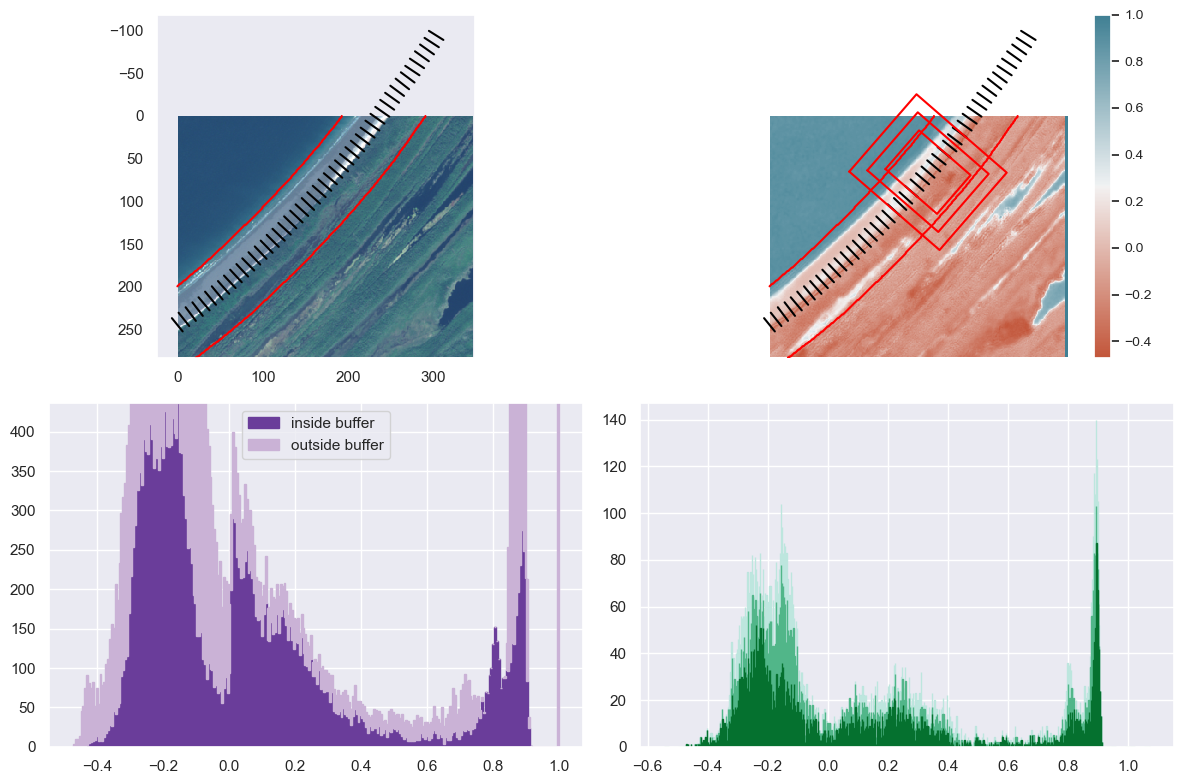

In [371]:
im_idx = 9
t_idxs = [20]
fig, axs = plt.subplots(2, 2, tight_layout=True, figsize=(12, 8))
axs = axs.ravel()
buffer = 150

im_idx = im_idx
im = ims[im_idx]
im_ind = indices.mndwi(im.reshape((-1, im.shape[-1]))).reshape(im.shape[:-1])
im_RGB = SDS_preprocess.rescale_image_intensity(im[:,:,[2,1,0]], cloud_masks[im_idx], 99.9)


axs[0].imshow(im_RGB, interpolation='none')
axs[0].grid(False)
plot_transects(axs[0], transects, output_epsg, im_epsgs[im_idx], georefs[im_idx])


plot_ind_im(axs[1], im_ind)
plot_transects(axs[1], transects, output_epsg, im_epsgs[im_idx], georefs[im_idx])

# plot contours
buffer_contours = sp_plt.mask_contour(im_buffers[im_idx])
for contour in buffer_contours:
        axs[0].plot(contour[:,1], contour[:,0], c="red")
        axs[1].plot(contour[:,1], contour[:,0], c="red")

# plot colliders
all_colliders_pxl = []
for j in range(4, 1, -1):
    colliders_pxl = [get_transect_collider(transects[t_idx], j * buffer, output_epsg, im_epsgs[im_idx], georefs[im_idx]) for t_idx in t_idxs]
    all_colliders_pxl.append(colliders_pxl)
    plot_colliders(axs[1], colliders_pxl)

# plot buffer relative histograms
hist_labels = ["inside buffer", "outside buffer"]
hist_pal = sns.color_palette(palette='Paired')
hist_colors = [hist_pal[-3], hist_pal[-4]] # light purple, dark purple
n, _, _ = axs[2].hist([im_ind[im_buffers[im_idx]], im_ind[~im_buffers[im_idx]]], bins=256, stacked=True, label=hist_labels, color=hist_colors, edgecolor=hist_colors)
axs[2].set_ylim(ymax=np.max(n[0])) # focus on values inside buffer
axs[2].legend()
hist_range = axs[2].get_xlim()

# plot collider relative histograms
masks = [get_collider_mask(colliders_pxl[0], im_ind.shape) & im_buffers[im_idx] for colliders_pxl in all_colliders_pxl]
data = [im_ind[mask].flatten() for mask in masks]
hist_pal = sns.color_palette(palette="BuGn")[1::2]
# n, _, _ = axs[3].hist(data, bins=256, color=hist_pal, edgecolor=hist_pal, range=hist_range)
n, _, _ = axs[3].hist(data, bins=512, edgecolor=hist_pal, range=hist_range)

# mini_cloud_masks = [cloud_masks[im_idx][mask] for mask in masks]
# mini_im_buffers = [im_buffers[im_idx][mask] for mask in masks]

# print([cm.shape for cm in mini_cloud_masks])
# print([d.shape for d in data])
# print([ib.shape for ib in mini_im_buffers])

# thresholds = [thresholding.local_min_otsu(d, cm, ib) for d, cm, ib in zip(data, mini_cloud_masks, mini_im_buffers)]
# ymin, ymax = axs[3].get_ylim()
# axs[3].vlines(thresholds, ymin, ymax, color=hist_pal)

